# AI-Powered Customer Intelligence & Churn Prediction Platform

## Project Overview

This project analyzes customer behaviour and predicts customer churn using data analysis and machine learning techniques.

The project combines exploratory data analysis, customer segmentation, machine learning, explainable AI, and business intelligence to identify customers who are at risk of leaving.

In [177]:
import pandas as pd
import numpy as np

In [178]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [179]:
df.shape

(7043, 33)

In [326]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


## Dataset Structure

Let's examine the columns available in the customer dataset.

In [182]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

### Data Types

Let's check what type of data each column contains.

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Missing Values

Let's check whether any customer information is missing.

In [186]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Data Type Correction

The Total Charges column is stored as text, so we will convert it into a numeric column for analysis.

In [189]:
df["Total Charges"].head()

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
Name: Total Charges, dtype: object

In [190]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [191]:
df["Total Charges"].dtype

dtype('float64')

## Duplicate Records

Let's check whether the dataset contains any duplicate customer records.

In [193]:
df.duplicated().sum()

0

## Customer Churn Distribution

Let's examine how many customers stayed with the company and how many customers churned.

In [195]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

## Churn Rate

Let's calculate the percentage of customers who churned and the percentage who stayed.

In [197]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Churn Distribution

The bar chart below shows the number of customers who stayed and the number who churned.

In [199]:
import matplotlib.pyplot as plt

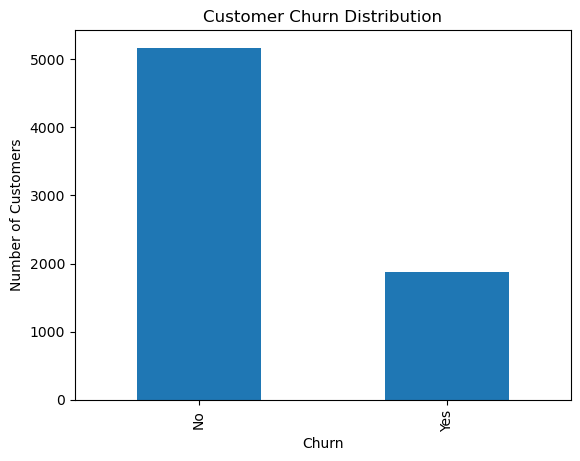

In [202]:
df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Churn by Contract Type

Let's compare customer churn across different contract types.

In [204]:
df.groupby("Contract")["Churn Value"].mean() * 100

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

## Churn Rate by Contract Type

The chart below compares the churn rate across different contract types.

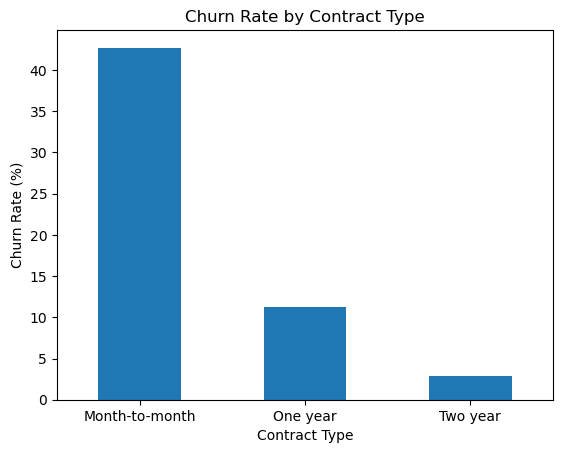

In [206]:
df.groupby("Contract")["Churn Value"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

## Churn by Customer Tenure

Let's examine whether customer churn changes depending on how long customers have been with the company.

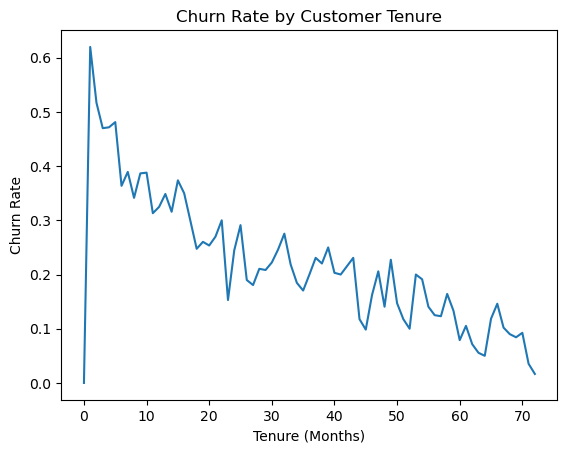

In [208]:
df.groupby("Tenure Months")["Churn Value"].mean().plot()

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.show()

## Churn by Internet Service

Let's compare customer churn across different internet service types.

In [228]:
df.groupby("Internet Service")["Churn Value"].mean() * 100

Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

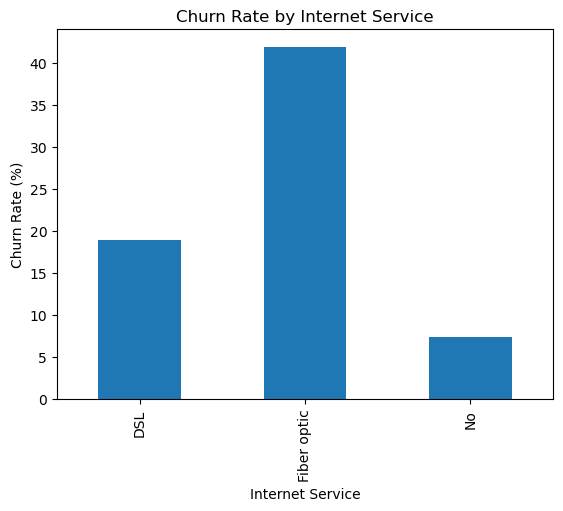

In [230]:


df.groupby("Internet Service")["Churn Value"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.show()

## Churn by Payment Method

Let's compare customer churn across different payment methods.

In [233]:
df.groupby("Payment Method")["Churn Value"].mean() * 100

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

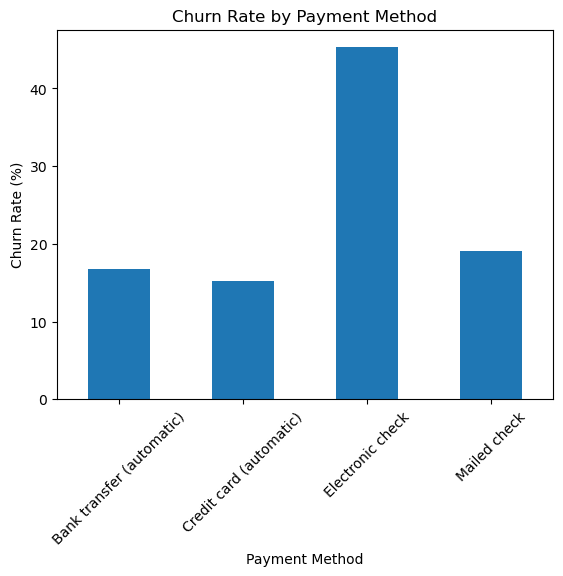

In [235]:

df.groupby("Payment Method")["Churn Value"].mean().mul(100).plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Preparing Data for Machine Learning

Machine learning models work with numerical data, so categorical customer information must be converted into numerical values.

In [238]:
df.select_dtypes(include="object").columns

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')

### Selecting Features and Target

We will use customer information to predict whether a customer will churn.
Churn Value will be our target variable.

In [241]:
X = df.drop(["Churn Label", "Churn Value", "Churn Score", "Churn Reason", "CustomerID"], axis=1)

y = df["Churn Value"]

In [243]:
X.shape, y.shape

((7043, 28), (7043,))

## Converting Categorical Data

Categorical values such as gender, contract type, and payment method need to be converted into numerical values before training the machine learning model.

### Preparing Clean Features for Machine Learning

We will remove identifiers and high-cardinality location fields before converting categorical variables into numerical features.

In [249]:
X = df.drop([
    "CustomerID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
], axis=1)

y = df["Churn Value"]

X = pd.get_dummies(X, drop_first=True)

X.shape

(7043, 34)

## Train-Test Split

We will divide the dataset into training and testing data. The model will learn from the training data and then be evaluated on unseen testing data.

In [252]:
from sklearn.model_selection import train_test_split

In [254]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((5634, 34), (1409, 34))

### Handling Missing Values

Some numerical values are missing after data type conversion. We will replace missing values using the median of the training data.

In [257]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [259]:
X_train.isnull().sum().sum()

0

### Feature Scaling

We will scale the features so that variables with different numerical ranges can be processed more effectively by the Logistic Regression model.

In [262]:
from sklearn.preprocessing import StandardScaler

In [264]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [266]:
from sklearn.linear_model import LogisticRegression

In [268]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [270]:
y_pred = model.predict(X_test_scaled)

y_pred[:10]

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0], dtype=int64)

## Model Evaluation

We will evaluate the Logistic Regression model to see how accurately it predicts customer churn.

In [273]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8026969481902059
Accuracy (%): 80.26969481902059


In [275]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[901 108]
 [170 230]]


In [277]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [279]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [280]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[0 0 0 1 0 1 1 0 1 0]


In [281]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.801277501774308
Random Forest Accuracy (%): 80.1277501774308


In [282]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1009
           1       0.71      0.51      0.59       400

    accuracy                           0.80      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [287]:
from sklearn.linear_model import LogisticRegression

In [289]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [291]:
y_pred = model.predict(X_test_scaled)

y_pred[:10]

array([1, 0, 0, 1, 0, 1, 1, 0, 1, 0], dtype=int64)

## Model Evaluation

We will evaluate how accurately the Logistic Regression model predicts customer churn.

In [294]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8026969481902059
Accuracy (%): 80.26969481902059


## Confusion Matrix

A confusion matrix helps us understand the correct and incorrect churn predictions made by the model.

In [297]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[901 108]
 [170 230]]


In [299]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [301]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [303]:
rf_pred = rf_model.predict(X_test)

rf_pred[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 0], dtype=int64)

In [305]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.801277501774308
Random Forest Accuracy (%): 80.1277501774308


In [307]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1009
           1       0.71      0.51      0.59       400

    accuracy                           0.80      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [328]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [329]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred[:10]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 0])

In [313]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Accuracy (%):", xgb_accuracy * 100)

XGBoost Accuracy: 0.7856635911994322
XGBoost Accuracy (%): 78.56635911994321


In [315]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1009
           1       0.65      0.53      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [317]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy * 100,
        rf_accuracy * 100,
        xgb_accuracy * 100
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,80.269695
1,Random Forest,80.127750
2,XGBoost,78.566359


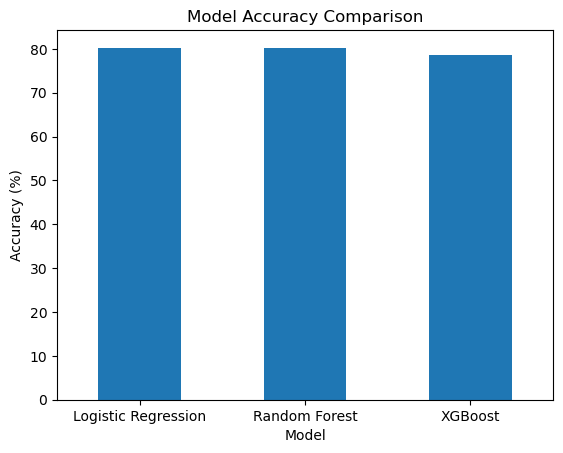

In [319]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=0)
plt.show()

In [321]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute Value"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute Value",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute Value
3,Tenure Months,-1.515393,1.515393
5,Total Charges,0.692158,0.692158
10,Dependents_Yes,-0.610268,0.610268
29,Contract_Two year,-0.599003,0.599003
14,Internet Service_Fiber optic,0.268161,0.268161
28,Contract_One year,-0.248800,0.248800
17,Online Security_Yes,-0.195589,0.195589
30,Paperless Billing_Yes,0.190659,0.190659
23,Tech Support_Yes,-0.172636,0.172636
13,Multiple Lines_Yes,0.139442,0.139442


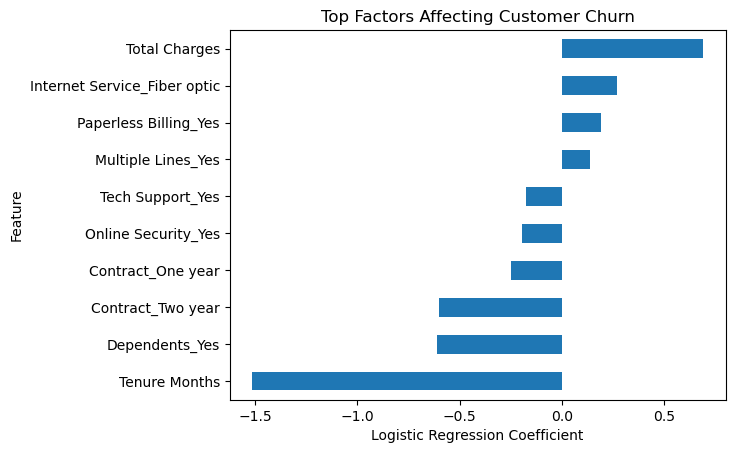

In [323]:
feature_importance.head(10).sort_values(
    "Coefficient"
).plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Top Factors Affecting Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

## Final Business Insights

Based on the exploratory data analysis and machine learning models, the following key insights were identified:

1. **Customer churn rate:** Approximately 26.54% of customers have churned, while 73.46% have remained with the company.

2. **Contract type:** Month-to-month customers have the highest churn rate (42.71%), while two-year contract customers have the lowest churn rate (2.83%).

3. **Internet service:** Fiber optic customers show a significantly higher churn rate (41.89%) compared with DSL customers (18.96%).

4. **Payment method:** Customers using electronic checks have the highest churn rate (45.29%).

5. **Customer tenure:** Churn generally decreases as customer tenure increases. Newer customers are more likely to leave.

6. **Important features:** Logistic Regression indicates that tenure, total charges, dependents, contract type, and internet service are among the important factors associated with customer churn.

7. **Model comparison:** Logistic Regression achieved the highest accuracy among the three tested models.

### Model Performance

- Logistic Regression: **80.27%**
- Random Forest: **80.13%**
- XGBoost: **78.57%**

### Business Recommendations

- Encourage month-to-month customers to move to one-year or two-year contracts.
- Provide special retention offers to new customers during their early months.
- Investigate customer dissatisfaction among fiber optic users.
- Review the electronic-check payment experience and encourage alternative payment methods.
- Promote services such as online security and technical support.
- Focus retention campaigns on customers showing characteristics associated with higher churn risk.

## Conclusion

The analysis demonstrates that customer churn is influenced by several factors, particularly contract type, tenure, internet service, payment method, and additional services. Among the tested models, Logistic Regression achieved the highest accuracy of approximately 80.27%.

These findings can help the company identify high-risk customers and develop targeted retention strategies to reduce customer churn.